# SALES PREDICTION USING PYTHON

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

file_path = "C:/Users/hp/OneDrive/Desktop/work/Encryptix/advertising.csv"
df = pd.read_csv(file_path)

# Data Preprocessing: Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Basic statistical analysis
print("Basic statistics of the dataset:")
print(df.describe())

Missing values in each column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
Basic statistics of the dataset:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


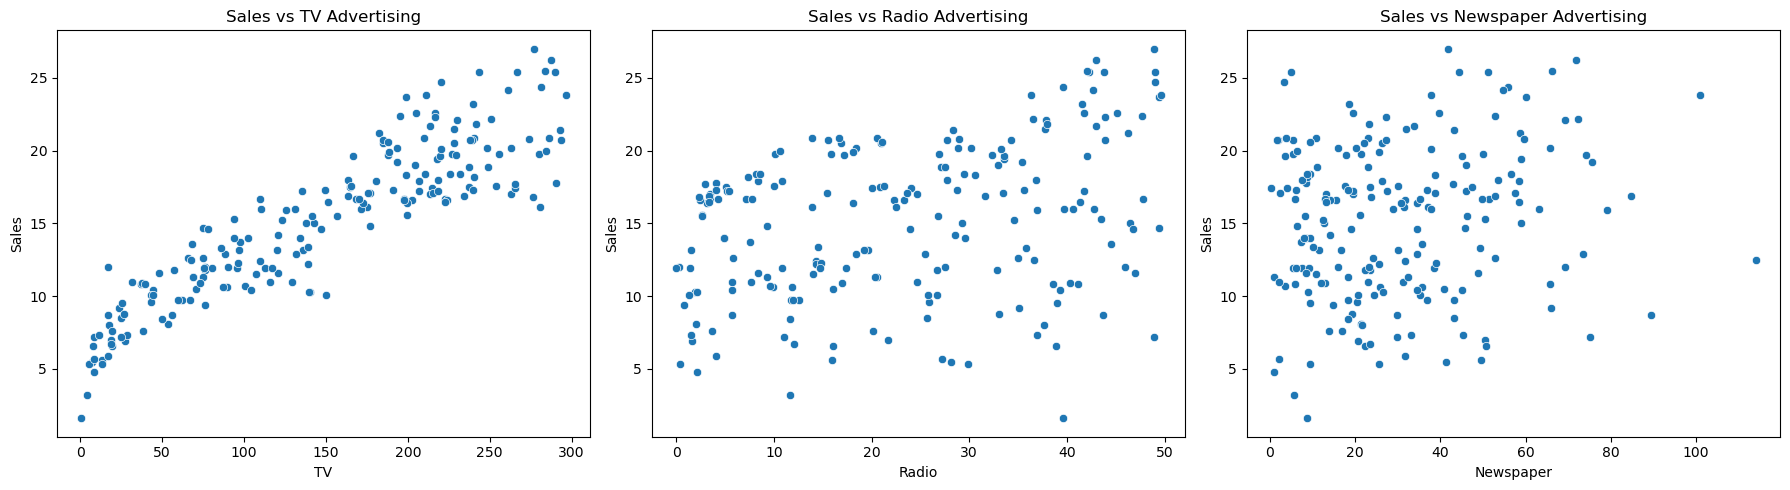

In [19]:
# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='TV', y='Sales', ax=axes[0])
axes[0].set_title('Sales vs TV Advertising')

sns.scatterplot(data=df, x='Radio', y='Sales', ax=axes[1])
axes[1].set_title('Sales vs Radio Advertising')

sns.scatterplot(data=df, x='Newspaper', y='Sales', ax=axes[2])
axes[2].set_title('Sales vs Newspaper Advertising')

plt.tight_layout()
plt.show()

In [22]:
# Correlation coefficients
correlation_matrix = df.corr()
print("Correlation matrix:")
print(correlation_matrix)

Correlation matrix:
                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


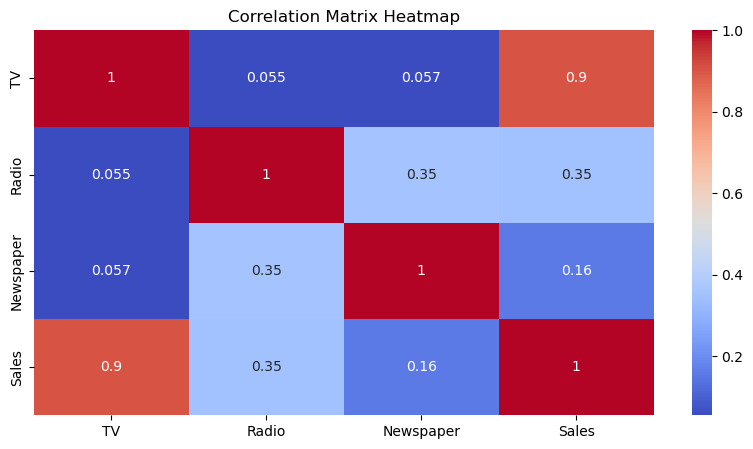

In [26]:
# Heatmap of the correlation matrix
plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [33]:
# Feature Selection: Selecting all features 
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training: Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Model Evaluation
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate metrics
train_rmse = mean_squared_error(y_train, y_pred_train, squared=False)
test_rmse = mean_squared_error(y_test, y_pred_test, squared=False)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print(f'Training RMSE: {train_rmse}')
print(f'Testing RMSE: {test_rmse}')
print(f'Training R^2: {train_r2}')
print(f'Testing R^2: {test_r2}')

Training RMSE: 1.6358920055378559
Testing RMSE: 1.7052146229349228
Training R^2: 0.9001416005862131
Testing R^2: 0.9059011844150826


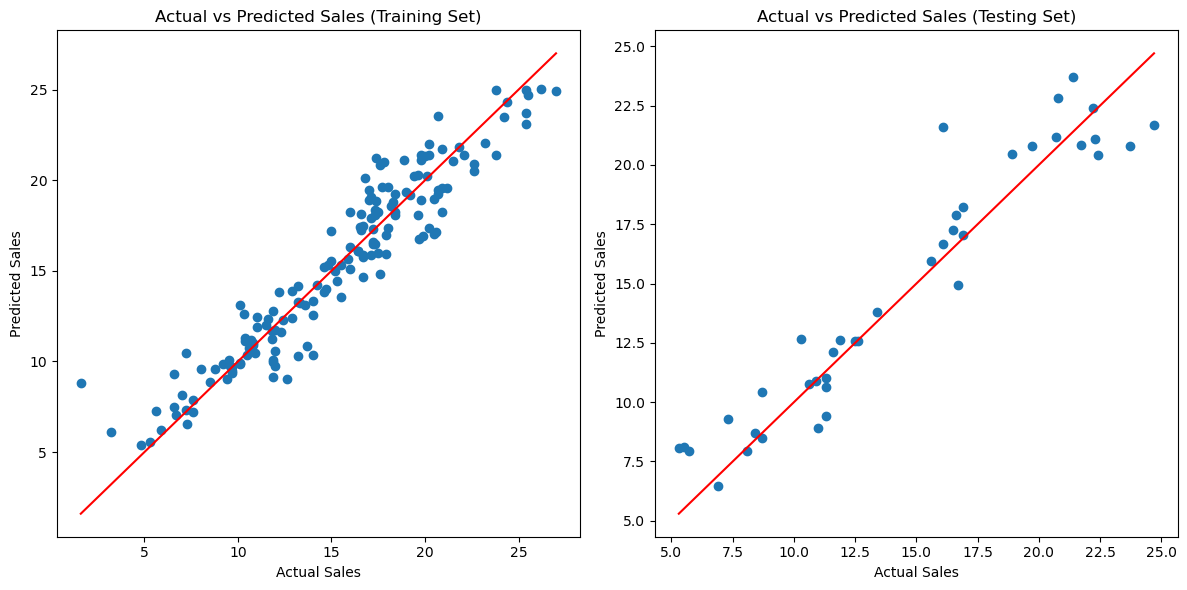

In [43]:
# Visualization of the results
plt.figure(figsize=(12, 6))

# Training set results
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Training Set)')

# Testing set results
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Testing Set)')

plt.tight_layout()
plt.show()

In [46]:
# Prediction: Using the model to predict sales on new data
new_data = pd.DataFrame({
    'TV': [150, 200],
    'Radio': [30, 40],
    'Newspaper': [20, 35]
})
predictions = model.predict(new_data)
print(f'Predictions for new data:\n{new_data}\n{predictions}')

Predictions for new data:
    TV  Radio  Newspaper
0  150     30         20
1  200     40         35
[16.00561084 19.8055777 ]
